# Building a Research Report Agent with LangGraph

In this notebook we'll build a small **multi-step research pipeline** that takes any topic and produces a fun, styled HTML report.

We'll keep the graph small and focus on the LangGraph essentials:

1. **State** with `TypedDict` + reducers
2. **Structured output** with Pydantic
3. **Nodes** as plain Python functions
4. **Edges** wiring nodes together

**Final pipeline** (4 nodes, linear):

```
START → planner → researcher → writer → compiler → END
```

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-openai langchain-tavily tavily-python pydantic jinja2 python-dotenv

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

---
## 1. State: what flows through the graph

The **state** is a `TypedDict` shared by every node. Each node reads from it and returns a dict of updates.

By default, returning a value for a key **overwrites** the previous value. For lists we want to **accumulate** results across nodes — that's what `Annotated[list, operator.add]` (a *reducer*) does.

In [3]:
import operator
from typing import Annotated, List, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


class Section(BaseModel):
    title: str = Field(description="Short, catchy section title")
    query: str = Field(description="A web search query that gathers info for this section")

class ReportPlan(BaseModel):
    sections: List[Section] = Field(description="3 to 4 sections that cover the topic")

class ResearchCritique(BaseModel):
    """Structured verdict on the research gathered so far."""
    sufficient: bool = Field(description="True if research is rich enough to write a great report")
    reason: str = Field(description="One short sentence explaining the verdict")
    follow_up_query: Optional[str] = Field(default=None, description="If not sufficient, ONE extra search query that closes the biggest gap")


class ReportState(TypedDict):
    topic: str
    plan: ReportPlan
    research: Annotated[list, operator.add]
    critique: Optional[ResearchCritique]
    iteration: int
    written_sections: Annotated[list, operator.add]
    final_html: str


---
## 2. The Planner Node

Our first node uses `llm.with_structured_output(ReportPlan)` to force the LLM to return a validated Pydantic object instead of free-form text. This makes downstream nodes reliable.

In [4]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-5.4-mini")

PLANNER_PROMPT = """You are a research planner. Given a topic, produce a plan with 3-4 sections.
Each section needs a short catchy title and ONE concrete web search query."""

def planner(state: ReportState) -> dict:
    structured = llm.with_structured_output(ReportPlan)
    plan = structured.invoke([
        {"role": "system", "content": PLANNER_PROMPT},
        {"role": "user", "content": f"Topic: {state['topic']}"},
    ])
    return {"plan": plan}

### Intermediate graph: just the planner

Before wiring everything together, let's test the planner as a tiny 1-node graph. This is the only intermediate graph we'll build — everything else goes into the final pipeline.

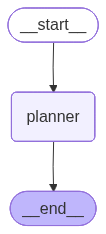

• Market Momentum → AI coding assistants market growth 2026 adoption statistics developer usage
• Top Tools and Players → best AI coding assistants in 2026 GitHub Copilot Cursor Claude Code JetBrains AI comparison
• Workflow Impact → how AI coding assistants change software development workflows 2026 productivity studies
• Risks and Governance → AI coding assistants security privacy hallucinations licensing issues 2026 best practices


In [5]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(ReportState)
builder.add_node("planner", planner)
builder.add_edge(START, "planner")
builder.add_edge("planner", END)
mini_graph = builder.compile()

display(Image(mini_graph.get_graph().draw_mermaid_png()))

DEMO_TOPIC = "The rise of AI coding assistants in 2026"
result = mini_graph.invoke({"topic": DEMO_TOPIC, "research": [], "written_sections": [], "final_html": ""})
for s in result["plan"].sections:
    print("•", s.title, "→", s.query)

---
## 3. The Researcher Node

For each section in the plan, we call the [Tavily](https://tavily.com/) search API and stash the results in state. Notice we return one big list — the `operator.add` reducer on `research` means everything accumulates.

In [6]:
from tavily import TavilyClient

tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def researcher(state: ReportState) -> dict:
    findings = []
    for section in state["plan"].sections:
        resp = tavily.search(query=section.query, max_results=3)
        findings.append({
            "section": section.title,
            "query": section.query,
            "results": resp.get("results", []),
        })
    return {"research": findings}

---
## 4. The Critic Node + Conditional Routing

A purely linear pipeline is boring. Let's add a **critic** node that uses structured output to judge whether the research is good enough. Based on its verdict, we **conditionally route** the graph either back to a follow-up researcher or forward to the writer.

This is where LangGraph stops looking like a script and starts looking like an *agent*: the graph itself decides what to do next.

In [7]:
from typing import Literal

CRITIC_PROMPT = """You are a strict research editor. Decide if the gathered research is rich and varied enough
to write a great multi-section report. If not, suggest ONE follow-up search query that would close the biggest gap."""

MAX_ITERATIONS = 2

def critic(state: ReportState) -> dict:
    summary_lines = []
    for f in state["research"]:
        section = f["section"]
        n = len(f["results"])
        titles = "; ".join(r.get("title", "") for r in f["results"])
        summary_lines.append(f"- {section} ({n} results): {titles}")
    summary = "\n".join(summary_lines)

    structured = llm.with_structured_output(ResearchCritique)
    topic = state["topic"]
    verdict = structured.invoke([
        {"role": "system", "content": CRITIC_PROMPT},
        {"role": "user", "content": f"Topic: {topic}\n\nResearch so far:\n{summary}"},
    ])
    return {"critique": verdict, "iteration": state.get("iteration", 0) + 1}


def route_after_critic(state: ReportState) -> Literal["researcher", "writer"]:
    """Conditional edge: loop back for more research, or move on to writing."""
    if state["iteration"] >= MAX_ITERATIONS:
        return "writer"  # safety valve
    if state["critique"] and state["critique"].sufficient:
        return "writer"
    return "researcher"


def follow_up_researcher(state: ReportState) -> dict:
    """When looped back, run the critic's suggested follow-up query."""
    q = state["critique"].follow_up_query if state["critique"] else None
    if not q:
        return {"research": []}
    resp = tavily.search(query=q, max_results=3)
    return {"research": [{"section": "Follow-up: " + q, "query": q, "results": resp.get("results", [])}]}


---
## 4. The Writer Node

The writer takes each section's research and asks the LLM to produce a short, well-written paragraph. We loop over sections and accumulate the results.

In [8]:
WRITER_PROMPT = """You are a sharp tech writer. Write ONE engaging paragraph (4-6 sentences)
for the section below using ONLY the provided research snippets. Be concrete and specific."""

def writer(state: ReportState) -> dict:
    written = []
    for finding in state["research"]:
        snippets = "\n\n".join(
            f"- {r.get('title','')}: {r.get('content','')}" for r in finding["results"]
        )
        msg = llm.invoke([
            {"role": "system", "content": WRITER_PROMPT},
            {"role": "user", "content": f"Section: {finding['section']}\n\nResearch:\n{snippets}"},
        ])
        written.append({"title": finding["section"], "body": msg.content, "sources": finding["results"]})
    return {"written_sections": written}

---
## 5. The Compiler Node

The compiler is a **pure Python node** — no LLM. It assembles the written sections into a styled, self-contained HTML report using a Jinja2 template. This shows that LangGraph nodes can be *any* Python function.

In [9]:
import jinja2, datetime
from pathlib import Path

EMOJIS = ["🚀", "🔬", "💡", "📊", "🌟", "🧠"]
OUTPUT_DIR = Path("output")

def _clean(s):
    """Strip lone surrogate code points that Tavily snippets sometimes contain."""
    if not isinstance(s, str):
        return s
    return "".join(c for c in s if not 0xD800 <= ord(c) <= 0xDFFF)

def _slug(s):
    return "".join(c if c.isalnum() else "-" for c in s.lower()).strip("-")[:60] or "report"

# Explicit light theme + !important so jupyter dark themes can\'t override readability.
TEMPLATE = """<!doctype html>
<html><head><meta charset=\'utf-8\'><title>{{ topic }}</title>
<style>
  .report-card { background: #ffffff !important; color: #1a1a1a !important;
    font-family: -apple-system, system-ui, sans-serif; max-width: 760px;
    margin: 1.5em auto; padding: 2em 2.5em; border-radius: 12px;
    box-shadow: 0 4px 24px rgba(0,0,0,0.12); line-height: 1.65; }
  .report-card h1 { color: #1a1a1a !important; font-size: 2em;
    border-bottom: 3px solid #3498db; padding-bottom: .35em; margin-top: 0; }
  .report-card h2 { color: #2c3e50 !important; margin-top: 1.8em; font-size: 1.35em; }
  .report-card p  { color: #1a1a1a !important; }
  .report-card .meta { color: #666 !important; font-size: .9em; margin-bottom: 1em; }
  .report-card .sources { background: #f6f8fa !important; color: #1a1a1a !important;
    font-size: .85em; padding: .8em 1.2em; border-left: 3px solid #3498db;
    margin-top: .6em; border-radius: 0 6px 6px 0; }
  .report-card .sources a { color: #2980b9 !important; text-decoration: none; }
  .report-card .sources a:hover { text-decoration: underline; }
  .report-card ul { margin: .4em 0 0 0; padding-left: 1.2em; }
</style></head><body>
<div class=\'report-card\'>
<h1>{{ topic }}</h1>
<div class=\'meta\'>Generated {{ date }}</div>
{% for s in sections %}
  <h2>{{ s.emoji }} {{ s.title }}</h2>
  <p>{{ s.body }}</p>
  <div class=\'sources\'><strong>Sources:</strong><ul>
    {% for r in s.sources %}<li><a href=\'{{ r.url }}\'>{{ r.title }}</a></li>{% endfor %}
  </ul></div>
{% endfor %}
</div></body></html>"""

def compiler(state: ReportState) -> dict:
    sections = []
    for i, s in enumerate(state["written_sections"]):
        sources = [{"url": _clean(r.get("url", "")), "title": _clean(r.get("title", ""))} for r in s["sources"]]
        sections.append({
            "title": _clean(s["title"]),
            "body": _clean(s["body"]),
            "sources": sources,
            "emoji": EMOJIS[i % len(EMOJIS)],
        })
    html = jinja2.Template(TEMPLATE).render(
        topic=_clean(state["topic"]),
        date=datetime.date.today().isoformat(),
        sections=sections,
    )
    # Save to disk so students can open the standalone file in a browser too.
    OUTPUT_DIR.mkdir(exist_ok=True)
    topic = state["topic"]
    out_path = OUTPUT_DIR / f"{_slug(topic)}.html"
    out_path.write_text(html, encoding="utf-8")
    print(f"📝 Report saved to {out_path}")
    return {"final_html": html}


---
## 6. The Final Graph

Now we wire all four nodes into a single linear pipeline.

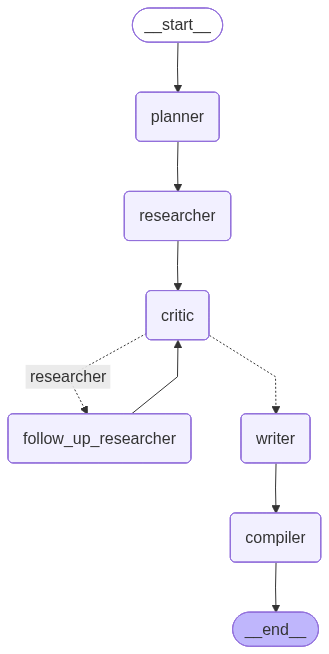

In [10]:
builder = StateGraph(ReportState)
builder.add_node("planner", planner)
builder.add_node("researcher", researcher)
builder.add_node("critic", critic)
builder.add_node("follow_up_researcher", follow_up_researcher)
builder.add_node("writer", writer)
builder.add_node("compiler", compiler)

builder.add_edge(START, "planner")
builder.add_edge("planner", "researcher")
builder.add_edge("researcher", "critic")
builder.add_conditional_edges("critic", route_after_critic, {
    "researcher": "follow_up_researcher",
    "writer": "writer",
})
builder.add_edge("follow_up_researcher", "critic")
builder.add_edge("writer", "compiler")
builder.add_edge("compiler", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


### Run the pipeline

In [11]:
from IPython.display import HTML

result = graph.invoke({
    "topic": DEMO_TOPIC,
    "research": [],
    "critique": None,
    "iteration": 0,
    "written_sections": [],
    "final_html": "",
})

HTML(result["final_html"])

📝 Report saved to output/the-rise-of-ai-coding-assistants-in-2026.html


---
## 7. Try Your Own Topic

Change the topic and re-run to generate a brand-new report.

In [12]:
MY_TOPIC = "Why octopuses are basically aliens"  # ← change me!

my_result = graph.invoke({
    "topic": MY_TOPIC,
    "research": [],
    "critique": None,
    "iteration": 0,
    "written_sections": [],
    "final_html": "",
})
HTML(my_result["final_html"])

📝 Report saved to output/why-octopuses-are-basically-aliens.html


---
## Recap

| Node | What it does | LangGraph idea |
|------|--------------|----------------|
| `planner` | Asks LLM for a section plan | Structured output with Pydantic |
| `researcher` | Tavily search per section | Reducer accumulates results |
| `writer` | LLM writes each section | Loop inside a node |
| `compiler` | Renders HTML | Pure Python node (no LLM) |

That's the whole pipeline. From here you could add: a quality-review loop, parallel section writing, charts, or persistent memory.